# The exemplars from *The Internal Logic of Symbulator*

The monograph [*The Internal Logic of Symbulator*](https://learn.symbulator.com/monograph.pdf) closes with seven exemplar circuits, chosen because each shows one thing the simulator is for. This notebook runs all of them, as the eight entries the app's Built-in Examples menu lists under *The Monograph* -- the circuits below are read from that same file, not retyped.

Each section gives the problem as the monograph poses it, draws the circuit, solves it, and reads the answer the text discusses. Run the cells in order; nothing here takes more than a few seconds.

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
from symbulator import dc, ac, fd, tr, th, draw, polar, bode_samples, t, s
import symbulator
symbulator.__version__

'0.5.30'

## 1. The two-stage amplifier of 1999

The circuit that closed the 1999 paper and the thesis's Problem 87: a two-stage amplifier whose gain Bode diagram Prof. Yee asked for. An FD solve returns every node voltage in s, and the gain is the Evaluate line, v4/v5. For the Bode plot itself, set vg to 1 (so v_4 is the transfer function) and plot v_4 between 1.6e3 and 1.6e12 Hz. Three minutes on the TI-89 in 2001; under a second here.

The analysis is in the s-domain, so `fd()`: every node voltage comes back as a function of `s`. A bare `a` would show all of them; the output node is enough here.

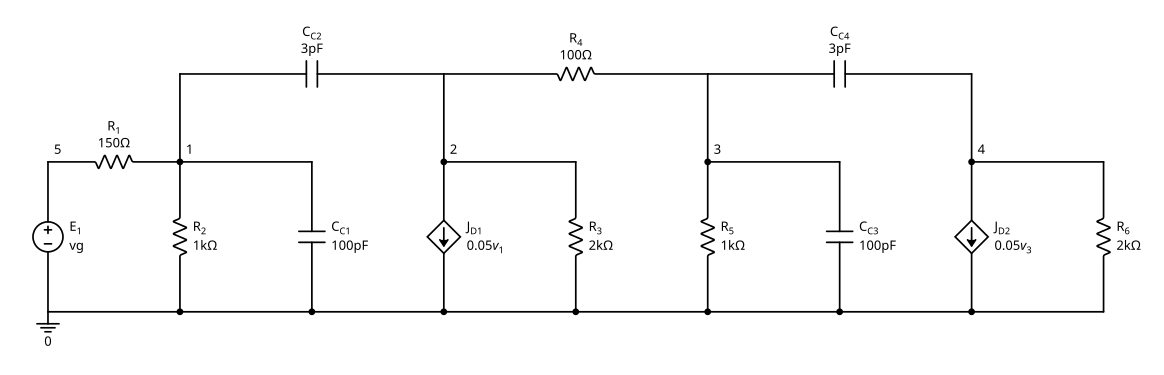

In [3]:
amp = '''
e1,5,0,vg
r1,5,1,150
r2,1,0,1'k
cc1,1,0,100'p
cc2,1,2,3'p
jd1,2,0,0.05*v_1
r3,2,0,2'k
r4,2,3,100
r5,3,0,1'k
cc3,3,0,100'p
cc4,3,4,3'p
jd2,4,0,0.05*v_3
r6,4,0,2'k
'''
draw(amp)

In [4]:
a = fd(amp)
a["v4"]

vg*(1.8e+17*s**2 - 6.0e+27*s + 5.0e+37)/(27.0*s**4 + 134010000000.0*s**3 + 8.6724075e+19*s**2 + 5.4981e+27*s + 1.7825e+34)

The gain is the ratio of two of those answers. The source is the symbol `vg`, and it cancels:

In [5]:
gain = sp.simplify(a["v4"] / a["v5"])
gain

(1.8e+17*s**2 - 6.0e+27*s + 5.0e+37)/(27.0*s**4 + 134010000000.0*s**3 + 8.6724075e+19*s**2 + 5.4981e+27*s + 1.7825e+34)

For the Bode diagram Prof. Yee asked for, `bode_samples()` sweeps the frequency and returns arrays ready for Matplotlib. With `vg` set to 1 by a condition, `v_4` *is* the transfer function.

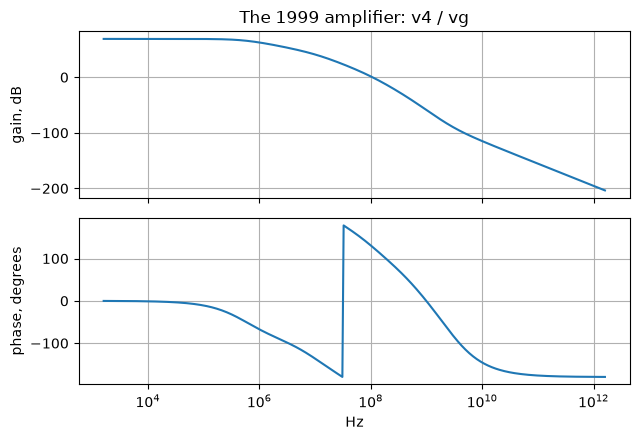

In [6]:
import matplotlib.pyplot as plt

freq, mag_db, phase = bode_samples(amp, "v_4", 1.6e3, 1.6e12, n=400, conditions=["vg = 1"])
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(freq, mag_db); a1.set_ylabel("gain, dB"); a1.grid(True, which="both")
a2.semilogx(freq, phase);  a2.set_ylabel("phase, degrees"); a2.set_xlabel("Hz"); a2.grid(True, which="both")
a1.set_title("The 1999 amplifier: v4 / vg")
plt.tight_layout()

## 2. One of each: the 2013 showcase

Composed in 2013 to show off: one dependent source of each species, woven through seven resistors. Find positive values of Es and Js such that the VCCS delivers 80 W and the CCVS dissipates 0 W. The two power constraints are quadratic, so four solutions exist; the conditions pick the one meant: Es = 17.61 V and Js = 0.3973 A. And ir5 comes out exactly 0 -- the constraint drove its own controlling current to zero, which is how the CCVS dissipates nothing.

This is Expert Mode: two equations about *power*, two unknowns that are the sources' own values, and two conditions that choose among the roots. Inside an equation the names are written the way the app writes them, `pjd1` for the power in `jd1`.

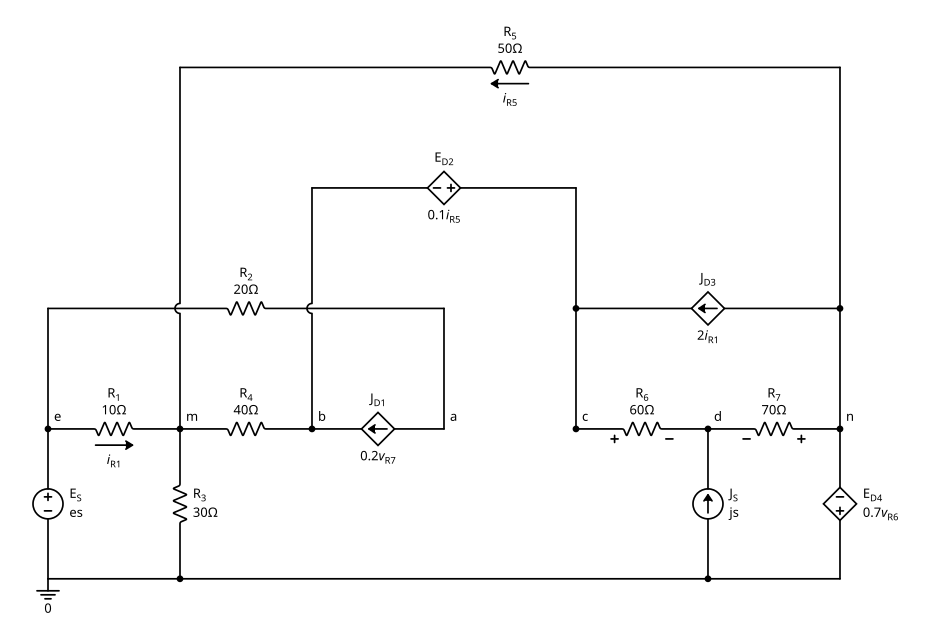

In [7]:
showcase = '''
es,e,0,es
js,0,d,js
r1,e,m,10
r2,a,e,20
r3,m,0,30
r4,b,m,40
r5,n,m,50
r6,c,d,60
r7,n,d,70
jd1,a,b,0.2vr7
ed2,c,b,0.1ir5
jd3,n,c,2ir1
ed4,0,n,0.7vr6
'''
draw(showcase)

In [8]:
sc = dc(showcase,
        unknowns=["es", "js"],
        equations=["pjd1 = -80", "ped2 = 0"],
        conditions=["es > 0", "js > 0"])
sc.rounded(4)

Result(domain='dc')
  es = 17.61
  i_ed2 = 1.469
  i_ed4 = 1.071
  i_es = 1.080
  i_jd1 = -1.676
  i_jd3 = 1.191
  i_js = 0.3973
  i_r1 = 0.5955
  i_r2 = 1.676
  i_r3 = 0.3886
  i_r4 = -0.2069
  i_r5 = 0
  i_r6 = -0.2776
  i_r7 = -0.1197
  js = 0.3973
  p_ed2 = 0
  p_ed4 = -12.49
  p_es = 19.02
  p_jd1 = -80.00
  p_jd3 = 9.859
  p_js = -7.960
  p_r1 = 3.547
  p_r2 = 56.15
  p_r3 = 4.531
  p_r4 = 1.713
  p_r5 = 0
  p_r6 = 4.623
  p_r7 = 1.003
  r_ed2 = 0
  r_ed4 = 10.88
  r_es = -16.31
  r_jd1 = 28.49
  r_jd3 = -6.949
  r_js = 50.44
  v_a = 51.13
  v_b = 3.381
  v_c = 3.381
  v_d = 20.04
  v_e = 17.61
  v_ed2 = 0
  v_ed4 = -11.66
  v_es = 17.61
  v_jd1 = 47.74
  v_jd3 = 8.277
  v_js = -20.04
  v_m = 11.66
  v_n = 11.66
  v_r1 = 5.955
  v_r2 = 33.51
  v_r3 = 11.66
  v_r4 = -8.277
  v_r5 = 0
  v_r6 = -16.66
  v_r7 = -8.378

The three answers the text names, and the current the constraint drove to zero:

In [9]:
sc.rounded(4)["es"], sc.rounded(4)["js"], sc["ir5"]

(17.61, 0.3973, 0.0)

Without the two conditions the system has more than one solution. `Result.solutions` holds all of them; `.values` is the first.

In [10]:
every = dc(showcase, unknowns=["es", "js"], equations=["pjd1 = -80", "ped2 = 0"])
len(every.solutions), [ (sp.N(sol["es"], 4), sp.N(sol["js"], 4)) for sol in every.solutions ]

(4, [(17.61, 0.3973), (-19.79, 3.495), (19.79, -3.495), (-17.61, -0.3973)])

## 3. Prof. Boulet's switching transient

Prof. Eliane Boulet's exam problem, the thesis's closing Problem 88, first interval: for t < 0 the 18 V source feeds the ladder and the capacitors sit open. DC gives their voltages -- va = 9 V and vb = 9/4 V -- the initial conditions the next entry carries.

Two entries, two analyses. First the DC state before the switch.

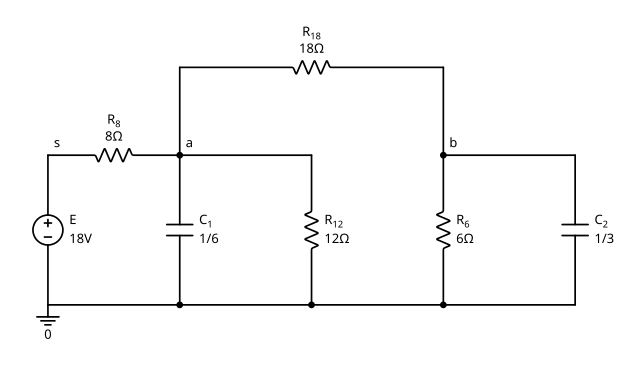

In [11]:
before = '''
e,s,0,18
r8,s,a,8
c1,a,0,1/6
r12,a,0,12
r18,a,b,18
r6,b,0,6
c2,b,0,1/3
'''
draw(before)

In [12]:
b0 = dc(before)
b0["va"], b0["vb"]

(9, 9/4)

The t > 0 half: the DC source gone, the waveform source connected, the capacitors starting from 9 and 9/4. Find the problem's v1 -- node a here, so the limited results ask for just va. The answer's two natural modes and the forced response are legible at a glance, va(0) checks out at exactly 9 V, and the 2001 calculator's printout agrees with this solve on every digit it displayed.

The circuit after the switch carries those two voltages as the capacitors' initial conditions, the fifth field on each `c` line. This one uses the cell magic: after `%load_ext symbulator`, a cell headed `%%tr` is a circuit, drawn and solved, with the options on the first line.

In [13]:
%load_ext symbulator

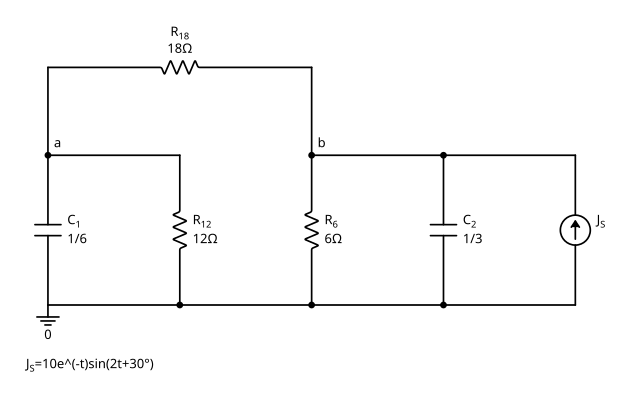

Result(domain='tr')
  v_a = ((-80*sin(2*t + pi/6) + 20*cos(2*t + pi/6) - 170*sqrt(3) + 153)*exp(t/2) + (193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/34

In [14]:
%%tr variables=v_a into=after
c1,a,0,1/6,9
r12,a,0,12
r18,a,b,18
r6,b,0,6
c2,b,0,1/3,9/4
js,0,b,10*e^(-t)*sin(2*t+30*pi/180)

The initial value checks out, and the response is easy to plot with the package's own `t`:

In [15]:
after.at("va", t=0)

9

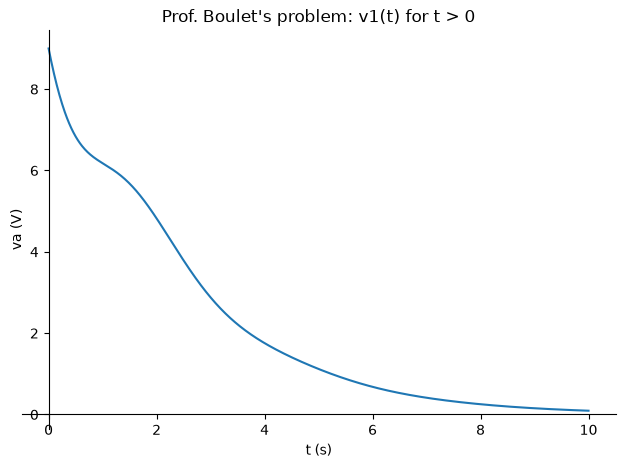

In [16]:
sp.plot(after["va"], (t, 0, 10), xlabel="t (s)", ylabel="va (V)", title="Prof. Boulet's problem: v1(t) for t > 0");

## 4. Three-phase wye-delta with line impedances

Alexander and Sadiku's Example 12.11, the balanced wye-delta with line impedances (Lesson 9 solves it too), the sources typed the way the book prints them. One AC call: aa(iraa) reads 2.350 at -36.20 degrees, and the Evaluate line's load line voltage 169.94 at 30.81 degrees. The exemplary part is what is absent: no wye-delta transformation, no single-phase equivalent.

An AC solve at a symbolic `omega` (the impedances are given as numbers already, so the frequency never enters). `polar()` is the app's `aa` mini-tool.

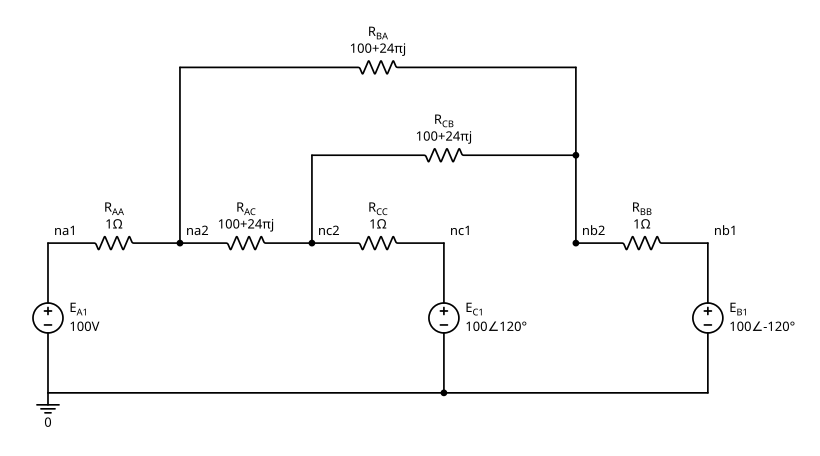

In [17]:
wye_delta = '''
ea1,na1,0,100
eb1,nb1,0,(100∠-120°)
ec1,nc1,0,(100∠120°)
raa,na1,na2,1
rbb,nb1,nb2,1
rcc,nc1,nc2,1
rac,na2,nc2,100+24*pi*j
rcb,nc2,nb2,100+24*pi*j
rba,nb2,na2,100+24*pi*j
'''
draw(wye_delta)

In [18]:
tp = ac(wye_delta, omega="omega")
tp.rounded(4)

Result(domain='ac')
  ap_ea1 = -94.82
  ap_eb1 = -94.82
  ap_ec1 = -94.82
  ap_raa = 2.762
  ap_rac = 92.06
  ap_rba = 92.06
  ap_rbb = 2.762
  ap_rcb = 92.06
  ap_rcc = 2.762
  i_ea1 = -1.896 + 1.388*I
  i_eb1 = 2.15 + 0.9482*I
  i_ec1 = -0.254 - 2.336*I
  i_raa = 1.896 - 1.388*I
  i_rac = 0.5475 - 1.242*I
  i_rba = -1.349 + 0.1467*I
  i_rbb = -2.15 - 0.9482*I
  i_rcb = 0.8015 + 1.095*I
  i_rcc = 0.254 + 2.336*I
  s_ea1 = -94.82 - 69.41*I
  s_eb1 = -94.82 - 69.41*I
  s_ec1 = -94.82 - 69.41*I
  s_raa = 2.762
  s_rac = 92.06 + 69.41*I
  s_rba = 92.06 + 69.41*I
  s_rbb = 2.762
  s_rcb = 92.06 + 69.41*I
  s_rcc = 2.762
  v_ea1 = 100.0
  v_eb1 = -50.0 - 86.6*I
  v_ec1 = -50.0 + 86.6*I
  v_na1 = 100.0
  v_na2 = 98.1 + 1.388*I
  v_nb1 = -50.0 - 86.6*I
  v_nb2 = -47.85 - 85.65*I
  v_nc1 = -50.0 + 86.6*I
  v_nc2 = -50.25 + 84.27*I
  v_raa = 1.896 - 1.388*I
  v_rac = 148.4 - 82.88*I
  v_rba = -146.0 - 87.04*I
  v_rbb = -2.15 - 0.9482*I
  v_rcb = -2.404 + 169.9*I
  v_rcc = 0.254 + 2.336*I
  z_ea

The line current the text reads, and the load's line voltage from two node voltages:

In [19]:
polar(tp["iraa"])

2.350∠-36.21°

In [20]:
polar(tp["vna2"] - tp["vnb2"], digits=5)

169.94∠30.811°

## 5. The ideal transformer, symbolically

From the teaching corpus, after AS7's Figure 13.33 (Lesson 10 has it too): everything in the description is a name. The Thevenin equivalent at the primary derives the referred-source and referred-impedance identities every machines course teaches -- vth = vs2/n and req = z2/n^2. When the answer to a symbolic question is the textbook's own theorem, the simulator has produced knowledge in the form the student is supposed to carry away.

`th()` takes the circuit and the two nodes of the port.

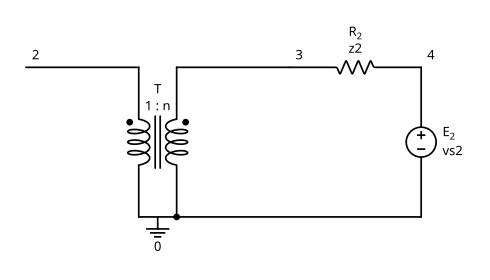

In [21]:
xfmr = '''
t,2,3,1,n
r2,3,4,z2
e2,4,0,vs2
'''
draw(xfmr)

In [22]:
th(xfmr, "2", "0", domain="dc")

TheveninResult(domain='dc', vth=vs2/n, ino=n*vs2/z2, req=z2/n**2, pmax=vs2**2/(4*z2))

## 6. Coupled coils with initial conditions

Composed for the monograph: two identical coupled coils, each closed on its own resistor, no sources anywhere -- the primary carries 1 A at t = 0 and the secondary is at rest. One TR call: il1 = (e^-t + e^-3t)/2 and il2 = (e^-t - e^-3t)/2, the circuit's common and differential modes in plain sight. Energy handed across the coupling and returned to heat, the whole story in two exponentials.

The `m` line couples the two inductors; the fourth field on `l1` is its initial current.

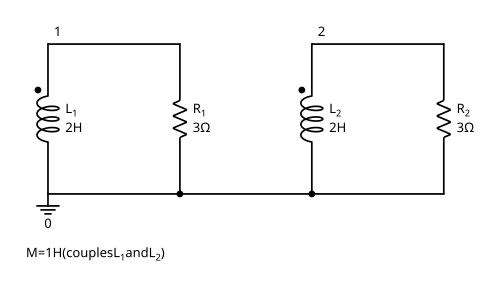

In [23]:
coils = '''
l1,1,0,2,1
r1,1,0,3
l2,2,0,2
r2,2,0,3
m,l1,l2,1
'''
draw(coils)

In [24]:
cc = tr(coils)
cc

Result(domain='tr')
  i_l1 = (exp(2*t) + 1)*exp(-3*t)/2
  i_l2 = (exp(2*t) - 1)*exp(-3*t)/2
  i_r1 = -(exp(2*t) + 1)*exp(-3*t)/2
  i_r2 = (1 - exp(2*t))*exp(-3*t)/2
  v_1 = -(3*exp(2*t) + 3)*exp(-3*t)/2
  v_2 = 3*(1 - exp(2*t))*exp(-3*t)/2

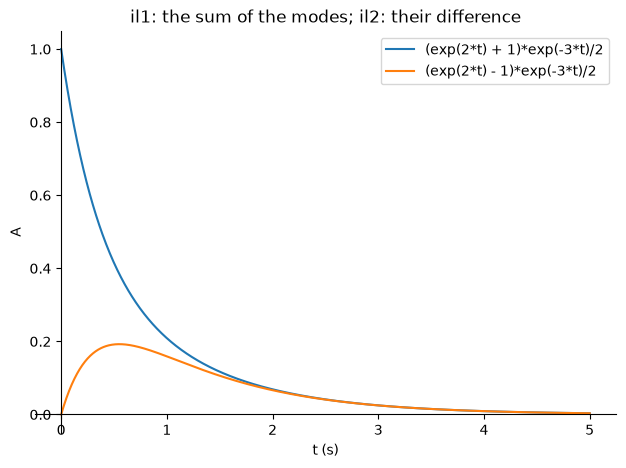

In [25]:
sp.plot(cc["il1"], cc["il2"], (t, 0, 5), xlabel="t (s)", ylabel="A", legend=True,
        title="il1: the sum of the modes; il2: their difference");

## 7. Two op-amps, all symbols

After Bobrow's Example 3.3 (Lesson 5 solves it too): a two-op-amp summing cascade in which every conductance is a symbol. The Evaluate line reads the gain, vo/vs = (g1-g2)/(g3-g4) -- a difference of conductances over a difference of conductances, so the circuit's structure is read directly off the expression. The single most persuasive demonstration of what Symbulator is for.

The resistors are written as reciprocals of conductances, so the gain comes out in the conductances. `vs` is the source's *value*, a symbol, not an answer, so the gain divides by the symbol itself.

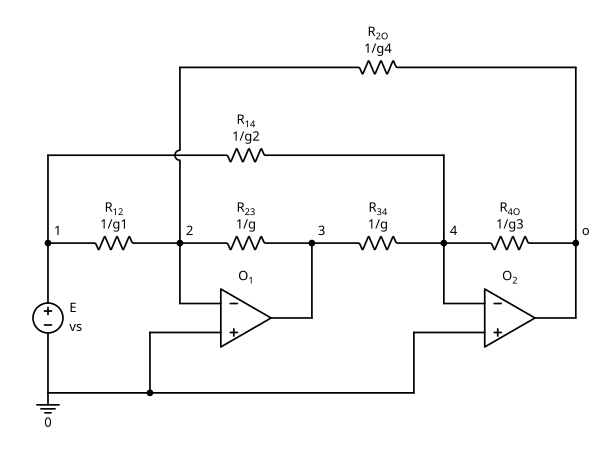

In [26]:
opamps = '''
e,1,0,vs
r12,1,2,1/g1
r14,1,4,1/g2
r23,2,3,1/g
r34,3,4,1/g
r2o,2,o,1/g4
r4o,4,o,1/g3
o1,0,2,3
o2,0,4,o
'''
draw(opamps)

In [27]:
oa = dc(opamps)
vs = sp.Symbol("vs")
sp.simplify(oa["vo"] / vs)

(g1 - g2)/(g3 - g4)

## Where next

* The monograph itself: https://learn.symbulator.com/monograph.pdf
* The same eight entries in the app, under *Built-in Examples › The Monograph*: https://symbulator.pythonanywhere.com/?input=monograph
* The package's quick start for notebooks, `quickstart.ipynb`, beside this file, and the README's *In a notebook* section.